# Import libraries

In [1]:
!pip install -q \
torch==2.7.1 \
torchvision==0.22.1 \
torchaudio==2.7.1 \
transformers==4.52.4 \
datasets==3.6.0 \
accelerate==1.7.0 \
evaluate==0.4.3 \
sentence-transformers==3.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import time
import torch

from sentence_transformers import SentenceTransformer
from datasets import Dataset
from transformers import AutoTokenizer
from transformers import AutoModelForSequenceClassification
from transformers import Trainer
from inference_utils import df_cleaning, build_embedding_matrix, add_minimal_clean_columns, predict_model, predict_roberta, prepare_test_dataset, prepare_test_embeddings
from model_utils import classify_analysis, classify_analysis_bert

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
PROCESS_DATA_PATH = "/content/drive/MyDrive/ML_course/Final_Project/preprocess_data"
MODEL_PATH = "/content/drive/MyDrive/ML_course/Final_Project/models"

with open(f"{PROCESS_DATA_PATH}/embedding_model_name.txt", "r") as f:
    EMBEDDING_MODEL_NAME = f.read().strip()

print(EMBEDDING_MODEL_NAME)

EMBEDDING_FEATURES = [
    "embedding_cosine",
    "embedding_euclidean"
]

with open(f"{PROCESS_DATA_PATH}/roberta_config.json", "r",) as f:
    config = json.load(f)

MAX_LENGTH = config["max_length"]


all-mpnet-base-v2


# Data Loading

In [4]:
raw_df = pd.read_csv('quora_question_pairs_test.csv.zip', index_col=0)
raw_df.head()

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
305985,429434,429435,Why is beef banned in India and not pork as well?,Is beef banned in india?,0
5193,10230,10231,At what valuation did Homejoy raise money in D...,Should a wealthy founder self-fund his second ...,0
123326,199422,199423,How do we judge?,How do I judge my love?,0
368557,327674,498931,Are Adderall and meth the same?,Are concerta and meth test the same?,0
369226,499645,499646,If you had internet access to only one site fo...,Why is there .co.uk for British internet sites...,0


In [5]:
df = df_cleaning(raw_df)

Deleted 0 rows
Label fixed for 0 examples
Deleted 0 rows due to label conflict, 0 rows due to duplication


In [6]:
y = df["is_duplicate"].values

## Sentence Embeddings

In [ ]:
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
df_se, emb_q1, emb_q2 = prepare_test_embeddings(df, embedding_model)

Batches:   0%|          | 0/316 [00:00<?, ?it/s]

Batches:   0%|          | 0/316 [00:00<?, ?it/s]

In [ ]:
X_se = build_embedding_matrix(df_se, emb_q1, emb_q2, feature_columns=EMBEDDING_FEATURES)

## Prepearing for RoBERTa

In [7]:
df_rb = add_minimal_clean_columns(df)

# Logistic regression

In [ ]:
logreg_model = joblib.load(f"{MODEL_PATH}/best_logistic_model_se1.joblib")

In [ ]:
predict_model(X_se, logreg_model)

Inference time: 0.1433 s


,prediction,probability,labels
0,1,0.503014,Duplicate
1,0,0.001875,Not duplicate
2,0,0.173660,Not duplicate
3,0,0.083641,Not duplicate
4,0,0.002711,Not duplicate
...,...,...,...
80853,0,0.294617,Not duplicate
80854,1,0.766378,Duplicate
80855,1,0.823264,Duplicate
80856,1,0.917786,Duplicate


Test
Log Loss      : 0.3380
ROC-AUC       : 0.9281
F1-score      : 0.8114
Inference time: 0.1368 s


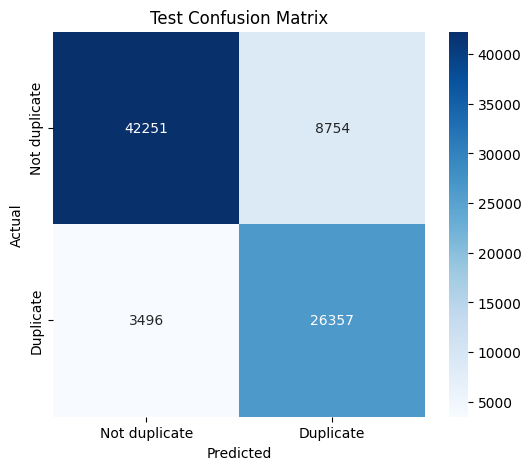


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.83      0.87     51005
           1       0.75      0.88      0.81     29853

    accuracy                           0.85     80858
   macro avg       0.84      0.86      0.84     80858
weighted avg       0.86      0.85      0.85     80858



{'log_loss': 0.33798995749586985,
 'roc_auc': 0.9280718296504816,
 'f1_score': 0.8114340249984607,
 'inference_time': 0.13684270007070154}

In [ ]:
classify_analysis(y, X_se, logreg_model, 'Test')

# XGBoost

In [ ]:
xgb_model = joblib.load(f"{MODEL_PATH}/xgboost_tfidf_se1.joblib")

In [ ]:
predict_model(X_se, xgb_model)

Inference time: 0.3271 s


,prediction,probability,labels
0,0,0.445317,Not duplicate
1,0,0.000247,Not duplicate
2,0,0.035753,Not duplicate
3,0,0.059985,Not duplicate
4,0,0.000231,Not duplicate
...,...,...,...
80853,0,0.031800,Not duplicate
80854,1,0.679029,Duplicate
80855,1,0.686915,Duplicate
80856,1,0.901861,Duplicate


Test
Log Loss      : 0.2783
ROC-AUC       : 0.9484
F1-score      : 0.8330
Inference time: 0.2594 s


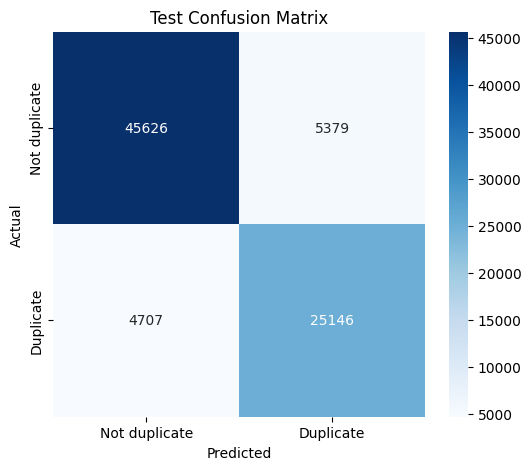


Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.89      0.90     51005
           1       0.82      0.84      0.83     29853

    accuracy                           0.88     80858
   macro avg       0.87      0.87      0.87     80858
weighted avg       0.88      0.88      0.88     80858



{'log_loss': 0.2783051251400822,
 'roc_auc': 0.9483950493450322,
 'f1_score': 0.8329523998807513,
 'inference_time': 0.25939469994045794}

In [ ]:
classify_analysis(y, X_se, xgb_model, 'Test')

# RoBERTa

In [8]:
tokenizer = AutoTokenizer.from_pretrained(f"{MODEL_PATH}/roberta")
model = AutoModelForSequenceClassification.from_pretrained(f"{MODEL_PATH}/roberta")

In [9]:
dt_rb = prepare_test_dataset(df_rb, tokenizer, MAX_LENGTH)

Map:   0%|          | 0/80858 [00:00<?, ? examples/s]

In [10]:
trainer = Trainer(model=model, processing_class=tokenizer)

In [12]:
predict_roberta(trainer, dt_rb)

Inference time: 388.1790 s


,prediction,probability,label
0,1,0.920879,Duplicate
1,0,0.000712,Not duplicate
2,0,0.000889,Not duplicate
3,0,0.001680,Not duplicate
4,0,0.000645,Not duplicate
...,...,...,...
80853,0,0.001240,Not duplicate
80854,0,0.015602,Not duplicate
80855,1,0.993861,Duplicate
80856,1,0.993696,Duplicate


Test
Log Loss      : 0.3696
ROC-AUC       : 0.9608
F1-score      : 0.8678
Inference time: 390.5055 s


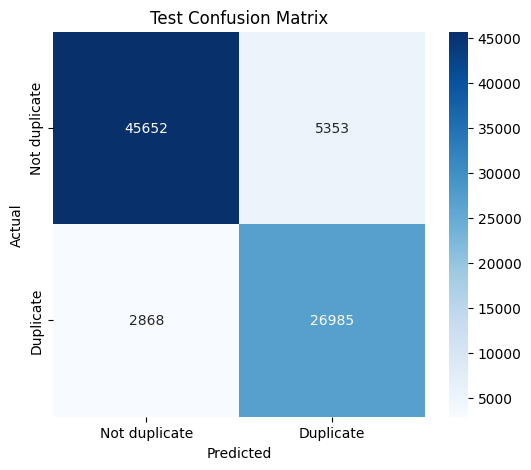


Classification Report:

              precision    recall  f1-score   support

           0     0.9409    0.8950    0.9174     51005
           1     0.8345    0.9039    0.8678     29853

    accuracy                         0.8983     80858
   macro avg     0.8877    0.8995    0.8926     80858
weighted avg     0.9016    0.8983    0.8991     80858



{'log_loss': 0.3696303353903689,
 'roc_auc': np.float64(0.9608067134750559),
 'f1_score': 0.8678104548889711,
 'inference_time': 390.5055,
 'y_true': array([0, 0, 0, ..., 1, 1, 0]),
 'y_pred': array([1, 0, 0, ..., 1, 1, 0]),
 'probabilities': array([[7.9121359e-02, 9.2087865e-01],
        [9.9928838e-01, 7.1167242e-04],
        [9.9911064e-01, 8.8936277e-04],
        ...,
        [6.1394218e-03, 9.9386060e-01],
        [6.3037286e-03, 9.9369627e-01],
        [9.9745923e-01, 2.5408284e-03]], dtype=float32)}

In [13]:
classify_analysis_bert(trainer, dt_rb, 'Test')